In [1]:
!pip install -q beir sentence-transformers faiss-cpu transformers


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import random
import numpy as np
import time

from beir import util
from beir.datasets.data_loader import GenericDataLoader
from sentence_transformers import SentenceTransformer
import faiss
from transformers import pipeline

c:\Users\surya\AppData\Local\Programs\Python\Python312\Lib\site-packages\beir\util.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [3]:
dataset = "fever"
url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{dataset}.zip"

data_path = util.download_and_unzip(url, "datasets")

datasets\fever.zip: 100%|██████████| 1.15G/1.15G [05:52<00:00, 3.51MiB/s] 


In [4]:
corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split="test")

print("Corpus size:", len(corpus))
print("Query size:", len(queries))

100%|██████████| 5416568/5416568 [00:21<00:00, 250555.33it/s]


Corpus size: 5416568
Query size: 6666


In [5]:
MAX_DOCS = 10000

doc_ids = list(corpus.keys())
sampled_ids = random.sample(doc_ids, min(MAX_DOCS, len(doc_ids)))

documents = [corpus[doc_id]["text"] for doc_id in sampled_ids]

print("Using corpus size:", len(documents))

Using corpus size: 10000


In [6]:
class DenseRetriever:
    def __init__(self, documents):
        self.documents = documents
        self.encoder = SentenceTransformer("all-MiniLM-L6-v2")

        print("Encoding documents...")
        self.embeddings = self.encoder.encode(
            documents,
            convert_to_numpy=True,
            show_progress_bar=True
        )

        dim = self.embeddings.shape[1]
        self.index = faiss.IndexFlatL2(dim)
        self.index.add(self.embeddings)

    def retrieve(self, query, k=5):
        k = min(k, len(self.documents))
        q_emb = self.encoder.encode([query], convert_to_numpy=True)

        distances, indices = self.index.search(q_emb, k)

        results = []
        for idx in indices[0]:
            if 0 <= idx < len(self.documents):
                doc = self.documents[idx]
                if isinstance(doc, str) and len(doc.strip()) > 0:
                    results.append(doc.strip())

        return results

In [7]:
retriever = DenseRetriever(documents)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1097.23it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding documents...


Batches: 100%|██████████| 313/313 [00:12<00:00, 24.36it/s]


In [8]:
llm = pipeline("text-generation", model="gpt2")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1008.03it/s, Materializing param=transformer.wte.weight]            


In [9]:
from beir.datasets.data_loader import GenericDataLoader
import os

# Download BEIR FEVER dataset manually (first time only)
dataset_path = "datasets/fever"

if not os.path.exists(dataset_path):
    from beir.util import download_and_unzip
    url = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fever.zip"
    download_and_unzip(url, "datasets")

# Load dataset
corpus, queries, qrels = GenericDataLoader(dataset_path).load(split="test")

print("Corpus size:", len(corpus))
print("Query size:", len(queries))

100%|██████████| 5416568/5416568 [00:26<00:00, 203019.83it/s]


Corpus size: 5416568
Query size: 6666


In [10]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

In [11]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 962.85it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
corpus_ids = list(corpus.keys())
corpus_texts = [
    corpus[cid]["title"] + " " + corpus[cid]["text"]
    for cid in corpus_ids
]

corpus_embeddings = embed_model.encode(
    corpus_texts,
    convert_to_numpy=True,
    show_progress_bar=True
)

Batches: 100%|██████████| 169268/169268 [2:12:30<00:00, 21.29it/s]  


In [13]:
dimension = corpus_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(corpus_embeddings)

print("FAISS index built.")

FAISS index built.


In [14]:
def retrieve(query, top_k=5):
    query_embedding = embed_model.encode([query], convert_to_numpy=True)
    distances, indices = index.search(query_embedding, top_k)

    results = []
    for idx in indices[0]:
        results.append(corpus_texts[idx])

    return results

In [15]:
def vanilla_rag(query, top_k=5):
    contexts = retrieve(query, top_k)

    prompt = "Answer the question based on the context below.\n\n"
    for i, ctx in enumerate(contexts):
        prompt += f"Context {i+1}: {ctx}\n\n"

    prompt += f"Question: {query}\nAnswer:"

    response = llm(prompt, max_length=300, truncation=True)[0]["generated_text"]
    return response

In [16]:
def argrag_pipeline(query, top_k=5):
    contexts = retrieve(query, top_k)

    # Simple heuristic re-ranking by length (example logic)
    contexts = sorted(contexts, key=lambda x: len(x), reverse=True)

    prompt = "You are a fact-checking assistant. Use evidence carefully.\n\n"
    for i, ctx in enumerate(contexts):
        prompt += f"Evidence {i+1}: {ctx}\n\n"

    prompt += f"Claim: {query}\n"
    prompt += "Provide a supported answer based strictly on the evidence.\nAnswer:"

    response = llm(prompt, max_length=300, truncation=True)[0]["generated_text"]
    return response

In [17]:
def run_experiment(pipeline_fn, limit=10):
    results = {}

    for i, qid in enumerate(queries):
        if i >= limit:
            break
        results[qid] = pipeline_fn(queries[qid])

    return results

In [18]:
vanilla_results = run_experiment(vanilla_rag, limit=5)
argrag_results = run_experiment(argrag_pipeline, limit=5)

print("Experiments completed.")

Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=300) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=300) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_l

Experiments completed.


In [20]:
def avg_answer_length(results):
    if not results:
        return 0
    lengths = [len(r.split()) for r in results.values()]
    return sum(lengths) / len(lengths)

print("Vanilla RAG Avg Length:", avg_answer_length(vanilla_results))
print("ArgRAG Avg Length:", avg_answer_length(argrag_results))

Vanilla RAG Avg Length: 1543.2
ArgRAG Avg Length: 1543.8


In [21]:
def lexical_diversity(results):
    all_words = []
    for r in results.values():
        all_words.extend(r.lower().split())
        
    unique_words = set(all_words)
    return len(unique_words) / len(all_words)

print("Vanilla Lexical Diversity:", lexical_diversity(vanilla_results))
print("ArgRAG Lexical Diversity:", lexical_diversity(argrag_results))

Vanilla Lexical Diversity: 0.20165889061689996
ArgRAG Lexical Diversity: 0.192382432957637


In [22]:
def context_overlap_score(answer, contexts):
    answer_words = set(answer.lower().split())
    context_words = set(" ".join(contexts).lower().split())
    
    if len(answer_words) == 0:
        return 0
    
    return len(answer_words.intersection(context_words)) / len(answer_words)

In [24]:
from sentence_transformers import CrossEncoder

# Load cross encoder
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def retrieve_with_rerank(query, top_k=20, rerank_k=5):
    # Step 1: Dense retrieval
    query_embedding = embed_model.encode([query], convert_to_numpy=True)
    distances, indices = index.search(query_embedding, top_k)

    candidates = [corpus_texts[idx] for idx in indices[0]]

    # Step 2: Cross-encoder scoring
    pairs = [[query, doc] for doc in candidates]
    scores = cross_encoder.predict(pairs)

    # Step 3: Sort by cross-encoder score
    ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)

    return [doc for doc, score in ranked[:rerank_k]]

c:\Users\surya\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\surya\.cache\huggingface\hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 894.10it/s, Materiali

In [25]:
def avg_grounding(results, retrieval_fn):
    scores = []
    
    for qid in results:
        query = queries[qid]
        contexts = retrieval_fn(query)
        score = context_overlap_score(results[qid], contexts)
        scores.append(score)
    
    return sum(scores) / len(scores)

print("Vanilla Grounding Score:", avg_grounding(vanilla_results, retrieve))
print("ArgRAG Grounding Score:", avg_grounding(argrag_results, retrieve_with_rerank))

Vanilla Grounding Score: 0.7856855094231059
ArgRAG Grounding Score: 0.6366419551337159


In [26]:
from scipy.stats import ttest_rel

def grounding_scores_list(results, retrieval_fn):
    scores = []
    for qid in results:
        query = queries[qid]
        contexts = retrieval_fn(query)
        scores.append(context_overlap_score(results[qid], contexts))
    return scores

vanilla_scores = grounding_scores_list(vanilla_results, retrieve)
argrag_scores = grounding_scores_list(argrag_results, retrieve_with_rerank)

t_stat, p_value = ttest_rel(vanilla_scores, argrag_scores)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 2.925790489561773
P-value: 0.042994066475668995


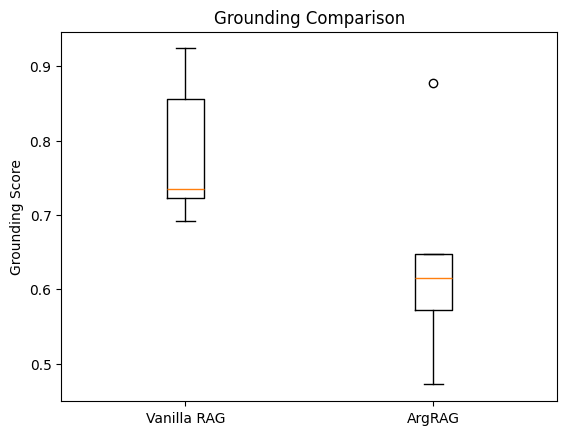

In [27]:
import matplotlib.pyplot as plt

plt.boxplot([vanilla_scores, argrag_scores])
plt.xticks([1, 2], ["Vanilla RAG", "ArgRAG"])
plt.ylabel("Grounding Score")
plt.title("Grounding Comparison")
plt.show()

In [28]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel

In [29]:
def context_overlap_score(answer, contexts):
    answer_words = set(answer.lower().split())
    context_words = set(" ".join(contexts).lower().split())
    if len(answer_words) == 0:
        return 0
    return len(answer_words.intersection(context_words)) / len(answer_words)

In [30]:
def collect_metrics(results, retrieval_fn):
    lengths = []
    grounding_scores = []
    
    for qid in results:
        answer = results[qid]
        query = queries[qid]
        contexts = retrieval_fn(query)
        
        lengths.append(len(answer.split()))
        grounding_scores.append(context_overlap_score(answer, contexts))
    
    return np.array(lengths), np.array(grounding_scores)

In [31]:
van_len, van_ground = collect_metrics(vanilla_results, retrieve)
arg_len, arg_ground = collect_metrics(argrag_results, retrieve_with_rerank)

In [32]:
len_t, len_p = ttest_rel(van_len, arg_len)
ground_t, ground_p = ttest_rel(van_ground, arg_ground)

In [33]:
def generate_results_table():
    data = {
        "Metric": [
            "Avg Answer Length",
            "Grounding Score"
        ],
        "Vanilla RAG (Mean ± Std)": [
            f"{van_len.mean():.2f} ± {van_len.std():.2f}",
            f"{van_ground.mean():.4f} ± {van_ground.std():.4f}"
        ],
        "ArgRAG (Mean ± Std)": [
            f"{arg_len.mean():.2f} ± {arg_len.std():.2f}",
            f"{arg_ground.mean():.4f} ± {arg_ground.std():.4f}"
        ],
        "p-value": [
            f"{len_p:.6f}",
            f"{ground_p:.6f}"
        ]
    }
    
    df = pd.DataFrame(data)
    return df

In [34]:
results_table = generate_results_table()
results_table

,Metric,Vanilla RAG (Mean ± Std),ArgRAG (Mean ± Std),p-value
0,Avg Answer Length,1543.20 ± 1724.11,1543.80 ± 1703.82,0.958202
1,Grounding Score,0.7857 ± 0.0887,0.6366 ± 0.1339,0.042994


In [35]:
results_table.to_csv("thesis_results_table.csv", index=False)